# Shabaka Pulse — Solar & Wind Forecasting Models

This notebook trains two independent XGBoost regression models to predict renewable power output in megawatts (MW):
1. **Benban Solar Park Model**: Predicts solar MW generation based on solar irradiance and temperature telemetry.
2. **Gulf of Suez Wind Farm Model**: Predicts wind MW generation based on wind speed, direction, and atmospheric telemetry.

Separate models are trained because solar and wind generation follow distinct physical conversion mechanisms, operating constraints, and contractual profiles.

## 1. Setup

Importing required libraries for data manipulation, machine learning, model serialization, and visualization.

We load `data/nasa_power_training_data.csv` into a pandas DataFrame with UTC timestamps as the index. A `models/` directory is created to store serialized model artifacts.

In [5]:
from typing import Union, Optional
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Directory for storing trained models and configuration files
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# Load prepared meteorological dataset
data_path = Path("data/nasa_power_training_data.csv")
df = pd.read_csv(data_path, index_col="timestamp_utc", parse_dates=True)

# Chronological split is used instead of train_test_split from sklearn
# to preserve time-series ordering and prevent future data leakage.

## 2. Generate physics-based training labels

Public NASA POWER telemetry provides meteorological measurements (irradiance, wind speed, temperature) rather than plant-level power output telemetry. To train forecasting models for the hackathon MVP, target MW generation labels are derived from standard physical conversion models:

1. **Solar Power Label**: Derived from Global Horizontal Irradiance (GHI) using plant capacity (1,800 MW) and a system performance derate factor (0.82). Small Gaussian noise (std = 15 MW) is added to model realistic operational noise (e.g., cloud transients, inverter clipping, panel degradation) so the regressor does not trivially fit a deterministic formula.
2. **Wind Power Label**: Derived using a standard wind turbine power curve function applied to 100m wind speed with cut-in (3 m/s), rated (12 m/s), and cut-out (25 m/s) thresholds for a 500 MW facility, combined with small Gaussian noise (std = 8 MW).

In [6]:
BENBAN_CAPACITY_MW = 1800.0
DERATE_FACTOR = 0.82
SUEZ_CAPACITY_MW = 500.0

np.random.seed(42)

# Solar power generation label (MW)
# Formula: P_solar = (GHI / 1000 W/m2) * Capacity_MW * Derate_Factor
ghi = df["allsky_sfc_sw_dwn"]
raw_solar_mw = (ghi / 1000.0) * BENBAN_CAPACITY_MW * DERATE_FACTOR
solar_noise = np.random.normal(loc=0.0, scale=15.0, size=len(df))
df["solar_mw"] = np.clip(raw_solar_mw + solar_noise, 0.0, BENBAN_CAPACITY_MW)


def wind_power_curve(
    wind_speed: Union[np.ndarray, pd.Series],
    capacity_mw: float = SUEZ_CAPACITY_MW,
    cut_in: float = 3.0,
    rated: float = 12.0,
    cut_out: float = 25.0,
) -> np.ndarray:
    """Calculates wind turbine power output using a standard piecewise power curve.

    Parameters
    ----------
    wind_speed : Union[np.ndarray, pd.Series]
        Wind speed at hub height (m/s).
    capacity_mw : float
        Total nameplate wind farm capacity (MW).
    cut_in : float
        Minimum wind speed for power generation (m/s).
    rated : float
        Wind speed at which rated capacity is reached (m/s).
    cut_out : float
        Maximum wind speed before shutdown for safety (m/s).

    Returns
    -------
    np.ndarray
        Power output in MW.
    """
    speed = np.asarray(wind_speed, dtype=float)
    power = np.zeros_like(speed)

    # Cubic ramp between cut-in and rated speeds
    ramp_mask = (speed >= cut_in) & (speed < rated)
    power[ramp_mask] = capacity_mw * (
        (speed[ramp_mask] - cut_in) / (rated - cut_in)
    ) ** 3.0

    # Constant rated output between rated and cut-out speeds
    rated_mask = (speed >= rated) & (speed < cut_out)
    power[rated_mask] = capacity_mw

    return power


# Wind power generation label (MW)
raw_wind_mw = wind_power_curve(df["ws100m"], capacity_mw=SUEZ_CAPACITY_MW)
wind_noise = np.random.normal(loc=0.0, scale=8.0, size=len(df))
df["wind_mw"] = np.clip(raw_wind_mw + wind_noise, 0.0, SUEZ_CAPACITY_MW)

# Display statistical summary of generated labels
label_summary = pd.DataFrame(
    {
        "solar_mw": [
            df["solar_mw"].min(),
            df["solar_mw"].max(),
            df["solar_mw"].mean(),
            (df["solar_mw"] == 0.0).sum(),
        ],
        "wind_mw": [
            df["wind_mw"].min(),
            df["wind_mw"].max(),
            df["wind_mw"].mean(),
            (df["wind_mw"] == 0.0).sum(),
        ],
    },
    index=["min_mw", "max_mw", "mean_mw", "zero_output_hours"],
)

display(label_summary.round(2))

,solar_mw,wind_mw
min_mw,0.00,0.00
max_mw,1610.49,500.00
mean_mw,402.47,164.63
zero_output_hours,2173.00,740.00


## 3. Feature selection

Selecting domain-specific features for each model:
- **Solar Features**: Focuses on irradiance variables (`allsky_sfc_sw_dwn`, `allsky_sfc_sw_dni`, `clrsky_sfc_sw_dwn`), ambient temperature at Benban (`t2m_benban`), and temporal signals (`hour_of_day`, `month`).
- **Wind Features**: Focuses on hub-height wind speed (`ws100m`), 50m wind speed (`ws50m`), air temperature at Suez (`t2m_suez`), and temporal signals (`hour_of_day`, `month`).

In [7]:
SOLAR_FEATURES = [
    "allsky_sfc_sw_dwn",
    "allsky_sfc_sw_dni",
    "clrsky_sfc_sw_dwn",
    "t2m_benban",
    "hour_of_day",
    "month",
]

WIND_FEATURES = [
    "ws100m",
    "ws50m",
    "t2m_suez",
    "hour_of_day",
    "month",
]

display(df[SOLAR_FEATURES].describe().round(2))
display(df[WIND_FEATURES].describe().round(2))

,allsky_sfc_sw_dwn,allsky_sfc_sw_dni,clrsky_sfc_sw_dwn,t2m_benban,hour_of_day,month
count,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,270.69,256.59,275.13,25.41,11.50,6.53
std,351.57,319.02,355.27,8.89,6.92,3.45
min,0.00,0.00,0.00,5.79,0.00,1.00
25%,0.00,0.00,0.00,19.01,5.75,4.00
50%,10.85,1.62,10.96,25.40,11.50,7.00
75%,577.99,574.00,593.67,32.01,17.25,10.00
max,1078.47,984.39,1078.97,47.19,23.00,12.00


,ws100m,ws50m,t2m_suez,hour_of_day,month
count,8760.00,8760.00,8760.00,8760.00,8760.00
mean,8.14,7.39,24.34,11.50,6.53
std,3.05,2.77,5.47,6.92,3.45
min,0.11,0.10,10.00,0.00,1.00
25%,6.10,5.54,19.95,5.75,4.00
50%,8.46,7.68,24.62,11.50,7.00
75%,10.26,9.31,28.59,17.25,10.00
max,17.51,15.89,38.64,23.00,12.00


## 4. Chronological train/test split

Time-series forecasting models must be evaluated chronologically to prevent temporal data leakage. We use a fixed date cutoff (`2025-11-01`):
- **Training Set**: January 1, 2025 to October 31, 2025 (first 10 months).
- **Test Set**: November 1, 2025 to December 31, 2025 (last 2 months).

In [8]:
SPLIT_DATE = "2025-11-01 00:00:00"

train_mask = df.index < SPLIT_DATE
test_mask = df.index >= SPLIT_DATE

X_train_solar = df.loc[train_mask, SOLAR_FEATURES]
y_train_solar = df.loc[train_mask, "solar_mw"]
X_test_solar = df.loc[test_mask, SOLAR_FEATURES]
y_test_solar = df.loc[test_mask, "solar_mw"]

X_train_wind = df.loc[train_mask, WIND_FEATURES]
y_train_wind = df.loc[train_mask, "wind_mw"]
X_test_wind = df.loc[test_mask, WIND_FEATURES]
y_test_wind = df.loc[test_mask, "wind_mw"]

split_summary = pd.DataFrame(
    {
        "set": ["Training Set", "Test Set"],
        "start_date": [df.index[train_mask].min(), df.index[test_mask].min()],
        "end_date": [df.index[train_mask].max(), df.index[test_mask].max()],
        "solar_rows": [len(X_train_solar), len(X_test_solar)],
        "wind_rows": [len(X_train_wind), len(X_test_wind)],
    }
)

display(split_summary)

,set,start_date,end_date,solar_rows,wind_rows
0,Training Set,2025-01-01,2025-10-31 23:00:00,7296,7296
1,Test Set,2025-11-01,2025-12-31 23:00:00,1464,1464


## 5. Train the solar model

Training an XGBoost Regressor for solar generation forecasting. Hyperparameters are selected for stable gradient boosting across seasonal variation:
- `n_estimators=200`: Allows sufficient boosting steps for diurnal patterns.
- `max_depth=5`: Captures non-linear temperature and irradiance interactions without overfitting.
- `learning_rate=0.05`: Provides conservative step sizes for smooth convergence.

In [9]:
solar_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
)

solar_model.fit(X_train_solar, y_train_solar)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## 6. Train the wind model

Training a separate XGBoost Regressor for wind generation forecasting using identical hyperparameter constraints to allow direct comparison of model performance.

In [10]:
wind_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
)

wind_model.fit(X_train_wind, y_train_wind)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## 7. Evaluate both models

Evaluating test-set performance using MW-appropriate regression metrics:
- **MAE (Mean Absolute Error, MW)**: Average absolute prediction error in MW.
- **RMSE (Root Mean Squared Error, MW)**: Measures error magnitude while penalizing larger outlier errors.
- **R2 Score**: Coefficient of determination measuring variance explained by the model.
- **Normalized MAE (%)**: (MAE / Capacity_MW) * 100, providing a capacity-normalized percentage error for fair comparison between Benban (1,800 MW) and Suez (500 MW).

In [11]:
# Predict on test set
solar_preds = solar_model.predict(X_test_solar)
wind_preds = wind_model.predict(X_test_wind)

# Compute Solar Metrics
solar_mae = mean_absolute_error(y_test_solar, solar_preds)
solar_rmse = np.sqrt(mean_squared_error(y_test_solar, solar_preds))
solar_r2 = r2_score(y_test_solar, solar_preds)
solar_nmae = (solar_mae / BENBAN_CAPACITY_MW) * 100.0

# Compute Wind Metrics
wind_mae = mean_absolute_error(y_test_wind, wind_preds)
wind_rmse = np.sqrt(mean_squared_error(y_test_wind, wind_preds))
wind_r2 = r2_score(y_test_wind, wind_preds)
wind_nmae = (wind_mae / SUEZ_CAPACITY_MW) * 100.0

metrics_df = pd.DataFrame(
    {
        "Capacity (MW)": [BENBAN_CAPACITY_MW, SUEZ_CAPACITY_MW],
        "MAE (MW)": [solar_mae, wind_mae],
        "RMSE (MW)": [solar_rmse, wind_rmse],
        "R2 Score": [solar_r2, wind_r2],
        "Normalized MAE (%)": [solar_nmae, wind_nmae],
    },
    index=["Solar Model (Benban)", "Wind Model (Suez)"],
)

display(metrics_df.round(3))

,Capacity (MW),MAE (MW),RMSE (MW),R2 Score,Normalized MAE (%)
Solar Model (Benban),1800.0,10.228,13.264,0.999,0.568
Wind Model (Suez),500.0,5.639,7.133,0.995,1.128


## 8. Visualize predictions vs actuals

Visualizing actual versus predicted output over the test period using time-series line charts and parity scatter plots (with 45-degree reference lines).

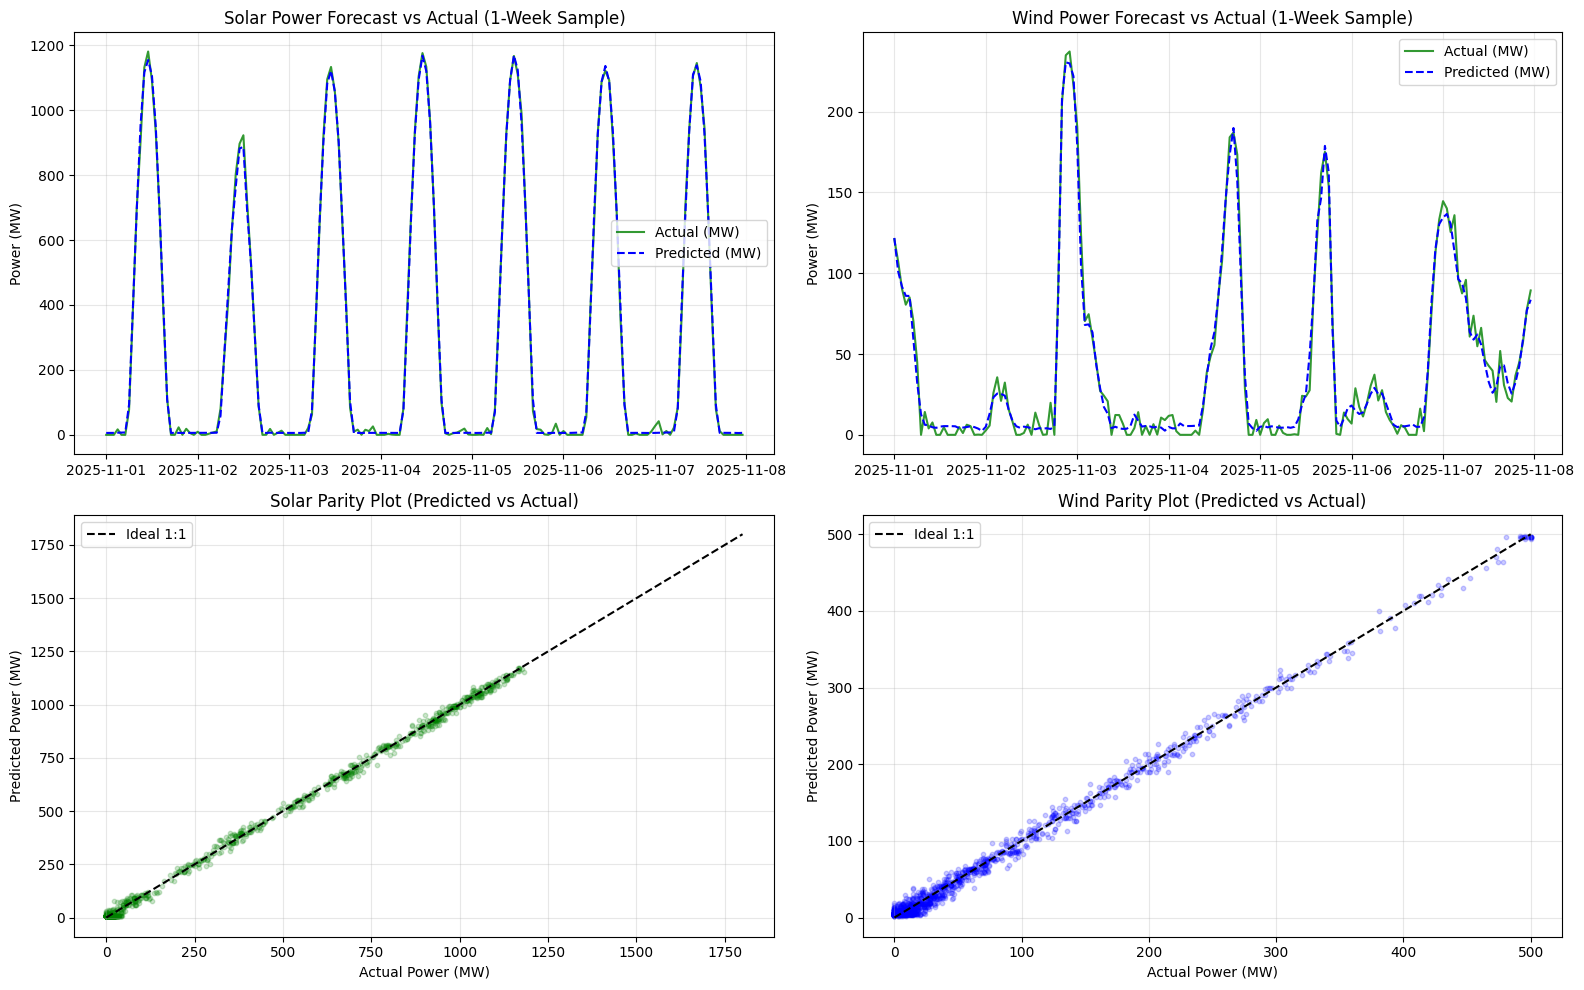

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Subplot 1: Solar Time-Series (First 168 hours / 1 week of test set for clarity)
sample_hours = 168
axes[0, 0].plot(
    y_test_solar.index[:sample_hours],
    y_test_solar.iloc[:sample_hours],
    label="Actual (MW)",
    color="green",
    alpha=0.8,
)
axes[0, 0].plot(
    y_test_solar.index[:sample_hours],
    solar_preds[:sample_hours],
    label="Predicted (MW)",
    color="blue",
    linestyle="--",
)
axes[0, 0].set_title("Solar Power Forecast vs Actual (1-Week Sample)")
axes[0, 0].set_ylabel("Power (MW)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Subplot 2: Wind Time-Series (First 168 hours of test set)
axes[0, 1].plot(
    y_test_wind.index[:sample_hours],
    y_test_wind.iloc[:sample_hours],
    label="Actual (MW)",
    color="green",
    alpha=0.8,
)
axes[0, 1].plot(
    y_test_wind.index[:sample_hours],
    wind_preds[:sample_hours],
    label="Predicted (MW)",
    color="blue",
    linestyle="--",
)
axes[0, 1].set_title("Wind Power Forecast vs Actual (1-Week Sample)")
axes[0, 1].set_ylabel("Power (MW)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Subplot 3: Solar Parity Scatter Plot
axes[1, 0].scatter(y_test_solar, solar_preds, alpha=0.2, color="green", s=10)
axes[1, 0].plot(
    [0, BENBAN_CAPACITY_MW],
    [0, BENBAN_CAPACITY_MW],
    "k--",
    label="Ideal 1:1",
)
axes[1, 0].set_title("Solar Parity Plot (Predicted vs Actual)")
axes[1, 0].set_xlabel("Actual Power (MW)")
axes[1, 0].set_ylabel("Predicted Power (MW)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Subplot 4: Wind Parity Scatter Plot
axes[1, 1].scatter(y_test_wind, wind_preds, alpha=0.2, color="blue", s=10)
axes[1, 1].plot(
    [0, SUEZ_CAPACITY_MW], [0, SUEZ_CAPACITY_MW], "k--", label="Ideal 1:1"
)
axes[1, 1].set_title("Wind Parity Plot (Predicted vs Actual)")
axes[1, 1].set_xlabel("Actual Power (MW)")
axes[1, 1].set_ylabel("Predicted Power (MW)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature importance

Inspecting XGBoost feature importance scores for both models to confirm physical validity (e.g., irradiance variables should dominate solar prediction, hub-height wind speed should dominate wind prediction).

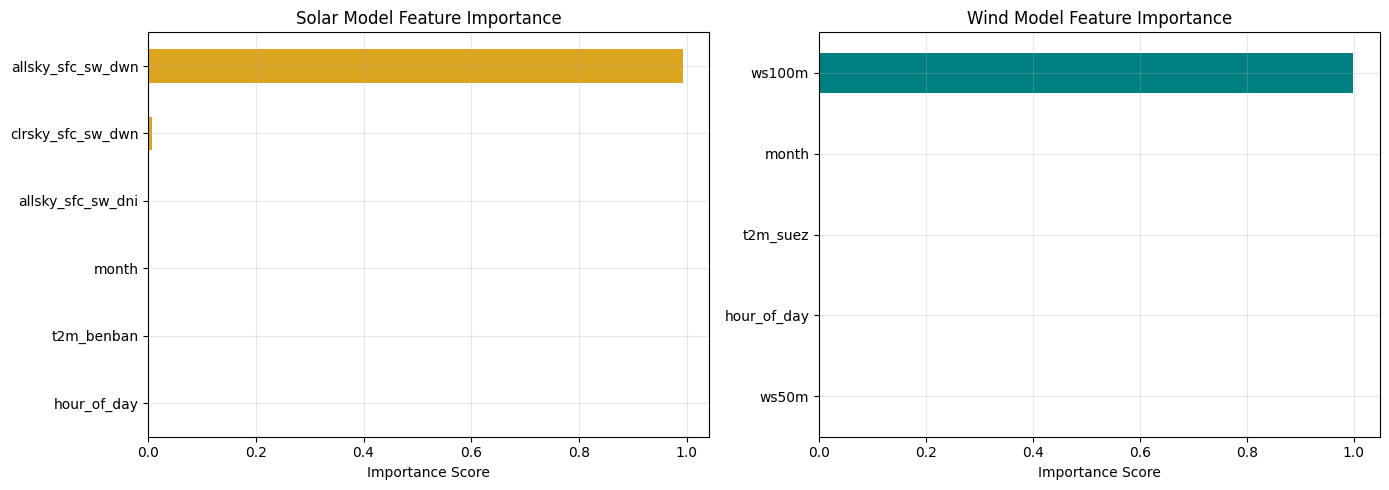

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solar Feature Importances
solar_importance = pd.Series(
    solar_model.feature_importances_, index=SOLAR_FEATURES
).sort_values()
solar_importance.plot(kind="barh", ax=axes[0], color="goldenrod")
axes[0].set_title("Solar Model Feature Importance")
axes[0].set_xlabel("Importance Score")
axes[0].grid(True, alpha=0.3)

# Wind Feature Importances
wind_importance = pd.Series(
    wind_model.feature_importances_, index=WIND_FEATURES
).sort_values()
wind_importance.plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title("Wind Model Feature Importance")
axes[1].set_xlabel("Importance Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Save trained models

Serializing trained XGBoost models to JSON (`models/solar_model.json`, `models/wind_model.json`) and writing feature list configurations (`models/feature_config.json`) so downstream applications can execute inference directly.

In [14]:
# Save model artifacts in XGBoost native JSON format
solar_model_path = MODELS_DIR / "solar_model.json"
wind_model_path = MODELS_DIR / "wind_model.json"

solar_model.save_model(solar_model_path)
wind_model.save_model(wind_model_path)

# Save feature configurations for inference pipeline alignment
feature_config = {
    "solar_features": SOLAR_FEATURES,
    "wind_features": WIND_FEATURES,
    "benban_capacity_mw": BENBAN_CAPACITY_MW,
    "suez_capacity_mw": SUEZ_CAPACITY_MW,
}

config_path = MODELS_DIR / "feature_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(feature_config, f, indent=2)

# Verify saved file paths and file sizes
saved_artifacts = [solar_model_path, wind_model_path, config_path]
artifact_info = pd.DataFrame(
    [
        {
            "file_name": p.name,
            "path": str(p.resolve()),
            "size_bytes": os.path.getsize(p),
        }
        for p in saved_artifacts
    ]
)

display(artifact_info)

,file_name,path,size_bytes
0,solar_model.json,D:\shabaka-pluse\models\solar_model.json,631256
1,wind_model.json,D:\shabaka-pluse\models\wind_model.json,670789
2,feature_config.json,D:\shabaka-pluse\models\feature_config.json,332
